# Maintenance Prédictive des Éoliennes
## Classification multiclasse — Turbine 1

Ce notebook couvre l'analyse exploratoire, le nettoyage des données, la construction d'un pipeline de preprocessing et la comparaison de plusieurs modèles de classification pour prédire les besoins de maintenance (labels 0, 1, 2).

**Métrique cible :** F1-Score macro — toutes les classes comptent également, y compris les pannes rares.

---
### Import des librairies

In [1]:
import os
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", message=".*disp.*",   category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*iprint.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", message=".*delayed.*", category=UserWarning)
os.environ["PYTHONWARNINGS"] = "ignore"

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import mlflow
import mlflow.sklearn

In [2]:
# Chargement du .env (contient AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY, etc.)
from dotenv import load_dotenv
load_dotenv()  # cherche .env dans le dossier courant (notebook/)

# Configuration MLflow
MLFLOW_TRACKING_URI = "https://atomik31-mlflow.hf.space"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("Wind_Turbine_Maintenance")

print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print("Experiment  : Wind_Turbine_Maintenance")
print(f"AWS key chargee : {bool(os.getenv('AWS_ACCESS_KEY_ID'))}")

# Dictionnaire pour suivre le meilleur modele
best_run = {"name": None, "f1_test": -1, "model": None, "params": {}}

Tracking URI : https://atomik31-mlflow.hf.space
Experiment  : Wind_Turbine_Maintenance
AWS key chargee : True


---
## Import du dataset

Les données proviennent d'un bucket S3 (accès via variables d'environnement). En développement local, on peut également charger les fichiers directement depuis `data/raw/`.

**Chargement local** — import depuis le dossier `data/raw/` (mode développement)

In [3]:
dataset = pd.read_csv('../data/raw/wind_turbine_maintenance_data.csv')

In [4]:
Turbine1 = dataset[dataset['Turbine_ID'] == 1]
Turbine2 = dataset[dataset['Turbine_ID'] == 2]

---
## 2. Nettoyage du dataset

On supprime les colonnes inutiles ou avec trop de valeurs manquantes. L'identifiant de turbine n'est plus nécessaire puisqu'on travaille sur Turbine 1 uniquement.

In [5]:
# Suppression des colonnes inutiles / trop de valeurs manquantes
useless_cols = ['Turbine_ID', 'Ambient_Temp_C', 'Humidity_pct']

print("Suppression des colonnes non pertinentes...")
Turbine1 = Turbine1.drop(useless_cols, axis=1)
print("Fait.")
print(Turbine1.head())

# Sauvegarde du dataset nettoyé dans le dossier processed
Turbine1.to_csv('../data/processed/dataset.csv', index=False)
print("\nDataset nettoyé sauvegardé dans data/processed/dataset.csv")

Suppression des colonnes non pertinentes...
Fait.
   Rotor_Speed_RPM  Wind_Speed_mps  Power_Output_kW  Gearbox_Oil_Temp_C  \
0        15.496714        7.861736      1564.768854           72.615149   
1        15.079832        7.840483      1502.222183           62.861035   
2        17.559488        8.394233      1512.221917           62.422822   
3        15.822545        6.779156      1520.886360           55.201649   
4        15.564464        8.025501      1547.319325           68.295953   

   Generator_Bearing_Temp_C  Vibration_Level_mmps  Maintenance_Label  
0                 73.829233              1.953173                  0  
1                 72.340913              1.976505                  0  
2                 71.998731              2.189488                  0  
3                 68.359070              2.039372                  0  
4                 86.703732              2.214197                  1  

Dataset nettoyé sauvegardé dans data/processed/dataset.csv


In [ ]:
# Upload dataset traité vers S3
import boto3
from pathlib import Path

S3_BUCKET   = "windscan"
S3_REGION   = "eu-north-1"
S3_DATA_KEY = "data/processed/"

s3 = boto3.client(
    "s3", region_name=S3_REGION,
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
)

dataset_local = Path("../data/processed/dataset.csv").resolve()
dataset_key   = S3_DATA_KEY + "dataset.csv"
s3.upload_file(str(dataset_local), S3_BUCKET, dataset_key)
print(f"Upload S3 OK : s3://{S3_BUCKET}/{dataset_key}")

---
## 3. Préparation des données

### Séparation features / cible

On isole la variable cible `Maintenance_Label` du reste des features.

In [6]:
# Séparation de la variable cible et des features
target_name = 'Maintenance_Label'

print("Séparation cible / features...")
Y = Turbine1[target_name]
X = Turbine1.drop(target_name, axis=1)
print("Fait.")
print(Y.head())
print()
print(X.head())
print()


Séparation cible / features...
Fait.
0    0
1    0
2    0
3    0
4    1
Name: Maintenance_Label, dtype: int64

   Rotor_Speed_RPM  Wind_Speed_mps  Power_Output_kW  Gearbox_Oil_Temp_C  \
0        15.496714        7.861736      1564.768854           72.615149   
1        15.079832        7.840483      1502.222183           62.861035   
2        17.559488        8.394233      1512.221917           62.422822   
3        15.822545        6.779156      1520.886360           55.201649   
4        15.564464        8.025501      1547.319325           68.295953   

   Generator_Bearing_Temp_C  Vibration_Level_mmps  
0                 73.829233              1.953173  
1                 72.340913              1.976505  
2                 71.998731              2.189488  
3                 68.359070              2.039372  
4                 86.703732              2.214197  



In [7]:
print("Découpage train / test (split chronologique)...")

# shuffle=False : on respecte l'ordre temporel des observations
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

print("Fait.")
print()
print(f"Train set : {X_train.shape}")
print(f"Test set  : {X_test.shape}")

print(f"\nDistribution des classes dans le train set :")
print(Y_train.value_counts(normalize=True))

Découpage train / test (split chronologique)...
Fait.

Train set : (14016, 6)
Test set  : (3504, 6)

Distribution des classes dans le train set :
Maintenance_Label
0    0.834332
2    0.084332
1    0.081336
Name: proportion, dtype: float64


In [8]:
# Vérification des features après séparation
X.head()

,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps
0,15.496714,7.861736,1564.768854,72.615149,73.829233,1.953173
1,15.079832,7.840483,1502.222183,62.861035,72.340913,1.976505
2,17.559488,8.394233,1512.221917,62.422822,71.998731,2.189488
3,15.822545,6.779156,1520.886360,55.201649,68.359070,2.039372
4,15.564464,8.025501,1547.319325,68.295953,86.703732,2.214197


### Preprocessing

On construit un pipeline de transformation : imputation des valeurs manquantes + standardisation pour les variables numériques, et encodage One-Hot pour les variables catégorielles (s'il y en a).

In [9]:
# Détection automatique des colonnes numériques et catégorielles
numeric_features = []
categorical_features = []

for col in X_train.columns:
    if pd.api.types.is_numeric_dtype(X_train[col]):
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print('Features numériques :', numeric_features)
print('Features catégorielles :', categorical_features)
print()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

transformers = [('num', numeric_transformer, numeric_features)]
if categorical_features:
    transformers.append(('cat', categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers)
print('Preprocesseur assemblé avec succès !')


Features numériques : ['Rotor_Speed_RPM', 'Wind_Speed_mps', 'Power_Output_kW', 'Gearbox_Oil_Temp_C', 'Generator_Bearing_Temp_C', 'Vibration_Level_mmps']
Features catégorielles : []

Preprocesseur assemblé avec succès !


In [10]:
# Application du preprocessing sur le train set (fit + transform)
print("Preprocessing du train set...")
print(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print('Fait.')
print(X_train[0:5, :])
print()

# Application sur le test set (transform uniquement, pas de re-fit !)
print("Preprocessing du test set...")
print(X_test.head())
X_test = preprocessor.transform(X_test)
print('Fait.')
print(X_test[0:5, :])
print()


Preprocessing du train set...
   Rotor_Speed_RPM  Wind_Speed_mps  Power_Output_kW  Gearbox_Oil_Temp_C  \
0        15.496714        7.861736      1564.768854           72.615149   
1        15.079832        7.840483      1502.222183           62.861035   
2        17.559488        8.394233      1512.221917           62.422822   
3        15.822545        6.779156      1520.886360           55.201649   
4        15.564464        8.025501      1547.319325           68.295953   

   Generator_Bearing_Temp_C  Vibration_Level_mmps  
0                 73.829233              1.953173  
1                 72.340913              1.976505  
2                 71.998731              2.189488  
3                 68.359070              2.039372  
4                 86.703732              2.214197  
Fait.
[[ 0.50241113 -0.14407207  0.64807446  1.5173422  -0.23704066 -0.23501827]
 [ 0.08286891 -0.16556134  0.02869452 -0.43283678 -0.53274673 -0.11765959]
 [ 2.57834635  0.39436531  0.12771873 -0.5204506  -

---
## 4. Modélisation

### Baseline — DummyClassifier

Avant tout modèle réel, on définit une baseline naïve : le `DummyClassifier` prédit toujours la classe majoritaire. C'est le plancher à dépasser absolument.

In [11]:
print("\n" + "="*80)
print("BASELINE — DummyClassifier")
print("=" * 80)

params_dummy = {"strategy": "most_frequent"}

with mlflow.start_run(run_name="Baseline_DummyClassifier"):
    dummy_clf = DummyClassifier(**params_dummy, random_state=42)
    dummy_clf.fit(X_train, Y_train)

    Y_train_pred = dummy_clf.predict(X_train)
    Y_test_pred  = dummy_clf.predict(X_test)

    f1_train = f1_score(Y_train, Y_train_pred, average="macro", zero_division=0)
    f1_test  = f1_score(Y_test,  Y_test_pred,  average="macro", zero_division=0)

    mlflow.log_params(params_dummy)
    mlflow.log_metrics({"f1_train": f1_train, "f1_test": f1_test})
    mlflow.sklearn.log_model(dummy_clf, "model")

    print(f"F1 macro Train : {f1_train:.4f}")
    print(f"F1 macro Test  : {f1_test:.4f}")

    if f1_test > best_run["f1_test"]:
        best_run = {"name": "DummyClassifier", "f1_test": f1_test,
                    "model": dummy_clf, "params": params_dummy}



BASELINE — DummyClassifier


2026/04/16 13:38:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/16 13:38:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


F1 macro Train : 0.3032
F1 macro Test  : 0.3035


🏃 View run Baseline_DummyClassifier at: https://atomik31-mlflow.hf.space/#/experiments/7/runs/b308ab09eb554d54a1134a8811b1732e
🧪 View experiment at: https://atomik31-mlflow.hf.space/#/experiments/7


### Sélection du modèle — tournoi de 3 approches

On compare trois approches par ordre croissant de complexité :
1. **Régression Logistique** (modèle linéaire simple)
2. **Régression Logistique L1 / Lasso** (sélection automatique de features)
3. **Random Forest** (modèle ensembliste non-linéaire)

Le F1-Score macro sur le test set détermine le meilleur candidat.

In [12]:
print("Regression Logistique...")

params_lr = {"solver": "lbfgs", "class_weight": "balanced", "max_iter": 1000}

with mlflow.start_run(run_name="LogisticRegression"):
    rl = LogisticRegression(**params_lr)
    rl.fit(X_train, Y_train)

    Y_train_pred = rl.predict(X_train)
    Y_test_pred  = rl.predict(X_test)

    f1_train = f1_score(Y_train, Y_train_pred, average="macro", zero_division=0)
    f1_test  = f1_score(Y_test,  Y_test_pred,  average="macro", zero_division=0)

    mlflow.log_params(params_lr)
    mlflow.log_metrics({"f1_train": f1_train, "f1_test": f1_test})
    mlflow.sklearn.log_model(rl, "model")

    print(f"F1 macro Train : {f1_train:.4f}")
    print(f"F1 macro Test  : {f1_test:.4f}")

    if f1_test > best_run["f1_test"]:
        best_run = {"name": "LogisticRegression", "f1_test": f1_test,
                    "model": rl, "params": params_lr}


Regression Logistique...


2026/04/16 13:39:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/16 13:39:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


F1 macro Train : 0.2144
F1 macro Test  : 0.2093


🏃 View run LogisticRegression at: https://atomik31-mlflow.hf.space/#/experiments/7/runs/04bfda3af73c4d44801a9f30320faa44
🧪 View experiment at: https://atomik31-mlflow.hf.space/#/experiments/7


In [13]:
print("\nLasso (Regression Logistique L1)...")

params_lasso = {"penalty": "l1", "solver": "saga", "C": 0.01,
                "class_weight": "balanced", "max_iter": 2000}

with mlflow.start_run(run_name="Lasso_L1"):
    lasso = LogisticRegression(**params_lasso, random_state=0)
    lasso.fit(X_train, Y_train)

    Y_train_pred = lasso.predict(X_train)
    Y_test_pred  = lasso.predict(X_test)

    f1_train = f1_score(Y_train, Y_train_pred, average="macro", zero_division=0)
    f1_test  = f1_score(Y_test,  Y_test_pred,  average="macro", zero_division=0)

    mlflow.log_params(params_lasso)
    mlflow.log_metrics({"f1_train": f1_train, "f1_test": f1_test})
    mlflow.sklearn.log_model(lasso, "model")

    print(f"F1 macro Train : {f1_train:.4f}")
    print(f"F1 macro Test  : {f1_test:.4f}")

    coeffs = np.sum(np.abs(lasso.coef_), axis=0)
    elim = [col for col, c in zip(X.columns, coeffs) if c == 0]
    if elim:
        print(f"Variables eliminees : {elim}")
    else:
        print("Aucune variable eliminee.")

    if f1_test > best_run["f1_test"]:
        best_run = {"name": "Lasso_L1", "f1_test": f1_test,
                    "model": lasso, "params": params_lasso}



Lasso (Regression Logistique L1)...


2026/04/16 13:39:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/16 13:39:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


F1 macro Train : 0.1588
F1 macro Test  : 0.1564
Variables eliminees : ['Rotor_Speed_RPM', 'Power_Output_kW', 'Gearbox_Oil_Temp_C', 'Generator_Bearing_Temp_C']


🏃 View run Lasso_L1 at: https://atomik31-mlflow.hf.space/#/experiments/7/runs/6ad56bccec55470ebe1b9dcb25aec777
🧪 View experiment at: https://atomik31-mlflow.hf.space/#/experiments/7


In [14]:
print("\nRandom Forest...")

# Params issus de la recherche manuelle (meilleur equilibre biais/variance)
params_rf = {"n_estimators": 100, "class_weight": "balanced",
             "max_depth": 10, "min_samples_split": 5,
             "min_samples_leaf": 4, "max_features": "log2"}

with mlflow.start_run(run_name="RandomForest"):
    rf = RandomForestClassifier(**params_rf, random_state=0)
    rf.fit(X_train, Y_train)

    Y_train_pred = rf.predict(X_train)
    Y_test_pred  = rf.predict(X_test)

    f1_train = f1_score(Y_train, Y_train_pred, average="macro", zero_division=0)
    f1_test  = f1_score(Y_test,  Y_test_pred,  average="macro", zero_division=0)

    mlflow.log_params(params_rf)
    mlflow.log_metrics({"f1_train": f1_train, "f1_test": f1_test})
    mlflow.sklearn.log_model(rf, "model")

    print(f"F1 macro Train : {f1_train:.4f}")
    print(f"F1 macro Test  : {f1_test:.4f}")

    if f1_test > best_run["f1_test"]:
        best_run = {"name": "RandomForest", "f1_test": f1_test,
                    "model": rf, "params": params_rf}



Random Forest...


2026/04/16 13:39:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/16 13:39:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


F1 macro Train : 0.7753
F1 macro Test  : 0.3413


🏃 View run RandomForest at: https://atomik31-mlflow.hf.space/#/experiments/7/runs/b7f08d9af128456d85b33118ca7fc5ea
🧪 View experiment at: https://atomik31-mlflow.hf.space/#/experiments/7


### Optimisation des hyperparamètres — Grid Search

Pour les deux meilleurs modèles, on effectue un Grid Search avec validation croisée stratifiée (5 folds) afin d'optimiser le F1-Score macro.

In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer

param_grid_lr = {
    "C": [0.005, 0.1, 1, 10, 100],
    "penalty": ["l1"],
    "solver": ["saga"],
    "class_weight": ["balanced"]
}

f1_scorer = make_scorer(f1_score, average="macro", zero_division=0)
cv_strat  = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=0, max_iter=2000, solver="saga"),
    param_grid=param_grid_lr, scoring=f1_scorer, cv=cv_strat, verbose=0, n_jobs=1
)

print("Grid Search — Regression Logistique...")
grid_lr.fit(X_train, Y_train)
best_lr = grid_lr.best_estimator_

f1_test_gs_lr  = f1_score(Y_test,  best_lr.predict(X_test),  average="macro", zero_division=0)
f1_train_gs_lr = f1_score(Y_train, best_lr.predict(X_train), average="macro", zero_division=0)

with mlflow.start_run(run_name="GridSearch_LogisticRegression"):
    mlflow.log_params(grid_lr.best_params_)
    mlflow.log_metrics({"f1_train": f1_train_gs_lr, "f1_test": f1_test_gs_lr,
                        "best_cv_score": grid_lr.best_score_})
    mlflow.sklearn.log_model(best_lr, "model")

print(f"Meilleurs params : {grid_lr.best_params_}")
print(f"F1 macro Test    : {f1_test_gs_lr:.4f}")

if f1_test_gs_lr > best_run["f1_test"]:
    best_run = {"name": "GridSearch_LR", "f1_test": f1_test_gs_lr,
                "model": best_lr, "params": grid_lr.best_params_}


Grid Search — Regression Logistique...


2026/04/16 13:40:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/16 13:40:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run GridSearch_LogisticRegression at: https://atomik31-mlflow.hf.space/#/experiments/7/runs/047b482f5ee84153b2bd97a123e19d42
🧪 View experiment at: https://atomik31-mlflow.hf.space/#/experiments/7


Meilleurs params : {'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
F1 macro Test    : 0.2090


In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

param_grid_rf = {
    "n_estimators": [30, 50],
    "max_depth": [5, 10],
    "min_samples_split": [2, 3],
    "min_samples_leaf": [2, 4],
    "class_weight": ["balanced", "balanced_subsample"]
}

f1_scorer = make_scorer(f1_score, average="macro", zero_division=0)

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=0),
    param_grid=param_grid_rf, scoring=f1_scorer, cv=5, verbose=0, n_jobs=1
)

print("Grid Search — Random Forest...")
grid_rf.fit(X_train, Y_train)
best_rf = grid_rf.best_estimator_

f1_test_gs_rf  = f1_score(Y_test,  best_rf.predict(X_test),  average="macro", zero_division=0)
f1_train_gs_rf = f1_score(Y_train, best_rf.predict(X_train), average="macro", zero_division=0)

with mlflow.start_run(run_name="GridSearch_RandomForest"):
    mlflow.log_params(grid_rf.best_params_)
    mlflow.log_metrics({"f1_train": f1_train_gs_rf, "f1_test": f1_test_gs_rf,
                        "best_cv_score": grid_rf.best_score_})
    mlflow.sklearn.log_model(best_rf, "model")

print(f"Meilleurs params : {grid_rf.best_params_}")
print(f"F1 macro Test    : {f1_test_gs_rf:.4f}")

if f1_test_gs_rf > best_run["f1_test"]:
    best_run = {"name": "GridSearch_RF", "f1_test": f1_test_gs_rf,
                "model": best_rf, "params": grid_rf.best_params_}


Grid Search — Random Forest...


2026/04/16 13:41:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/16 13:41:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run GridSearch_RandomForest at: https://atomik31-mlflow.hf.space/#/experiments/7/runs/172fa892f2c6474a84d3203dfd299df1
🧪 View experiment at: https://atomik31-mlflow.hf.space/#/experiments/7


Meilleurs params : {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
F1 macro Test    : 0.3366


### Historique des itérations manuelles — Random Forest

Avant le Grid Search, plusieurs configurations ont été testées manuellement pour comprendre le comportement du modèle.
Le code ci-dessous reproduit ces 3 configurations et affiche les scores réels.

In [17]:
# Comparaison des 3 configurations RF testees manuellement
# Les labels reflètent le résultat réel observé
configs = [
    {"n_estimators": 200, "max_depth": 15, "min_samples_split": 8, "min_samples_leaf": 2,  "note": "Overfitting_fort"},
    {"n_estimators": 100, "max_depth": 10, "min_samples_split": 5, "min_samples_leaf": 4,  "note": "Params_retenus"},
    {"n_estimators": 200, "max_depth": 5,  "min_samples_split": 5, "min_samples_leaf": 4,  "note": "Sous_apprentissage"},
]

rows = []
for cfg in configs:
    params = {k: v for k, v in cfg.items() if k != "note"}
    rf_tmp = RandomForestClassifier(**params, class_weight="balanced", random_state=0)
    rf_tmp.fit(X_train, Y_train)
    f1_tr = f1_score(Y_train, rf_tmp.predict(X_train), average="macro", zero_division=0)
    f1_te = f1_score(Y_test,  rf_tmp.predict(X_test),  average="macro", zero_division=0)

    with mlflow.start_run(run_name=f"RF_manual_{cfg['note']}"):
        mlflow.log_params({**params, "class_weight": "balanced"})
        mlflow.log_metrics({"f1_train": f1_tr, "f1_test": f1_te})
        mlflow.sklearn.log_model(rf_tmp, "model")

    # Participe à la sélection du meilleur modèle
    if f1_te > best_run["f1_test"]:
        best_run = {"name": f"RF_manual_{cfg['note']}", "f1_test": f1_te,
                    "model": rf_tmp, "params": {**params, "class_weight": "balanced"}}

    rows.append({**params,
        "F1 Train": round(f1_tr, 4),
        "F1 Test":  round(f1_te, 4),
        "Ecart":    round(f1_tr - f1_te, 4),
        "Remarque": cfg["note"],
    })

df_history = pd.DataFrame(rows)
display(df_history)


2026/04/16 13:41:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/16 13:42:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RF_manual_Overfitting_fort at: https://atomik31-mlflow.hf.space/#/experiments/7/runs/821e5b7477e948aa8cffd92ba554447e
🧪 View experiment at: https://atomik31-mlflow.hf.space/#/experiments/7


2026/04/16 13:42:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/16 13:42:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RF_manual_Params_retenus at: https://atomik31-mlflow.hf.space/#/experiments/7/runs/980a67d46a7b4bafbc2ad64462d62164
🧪 View experiment at: https://atomik31-mlflow.hf.space/#/experiments/7


2026/04/16 13:42:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/16 13:42:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RF_manual_Sous_apprentissage at: https://atomik31-mlflow.hf.space/#/experiments/7/runs/cd951b0eca3b4223ab4e03d763f828d7
🧪 View experiment at: https://atomik31-mlflow.hf.space/#/experiments/7


,n_estimators,max_depth,min_samples_split,min_samples_leaf,F1 Train,F1 Test,Ecart,Remarque
0,200,15,8,2,0.9932,0.3089,0.6843,Overfitting_fort
1,100,10,5,4,0.7753,0.3413,0.4339,Params_retenus
2,200,5,5,4,0.3562,0.2554,0.1007,Sous_apprentissage


### Importance des variables

On visualise les features les plus déterminantes pour le Random Forest. Cela permet de valider que le modèle s'appuie sur des signaux physiquement cohérents (vibrations, température, etc.).

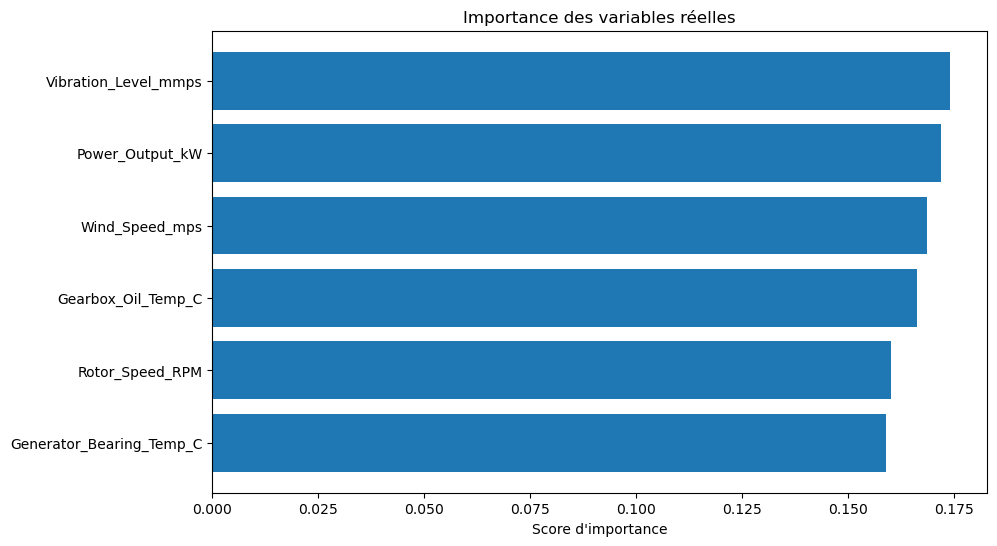

                    Feature  Importance
5      Vibration_Level_mmps    0.174153
2           Power_Output_kW    0.172051
1            Wind_Speed_mps    0.168559
3        Gearbox_Oil_Temp_C    0.166238
0           Rotor_Speed_RPM    0.160110
4  Generator_Bearing_Temp_C    0.158888


In [18]:
# 1. RÉCUPÉRATION DES NOMS (L'erreur était ici)
# On ne veut pas les données de X, on veut ses TITRES de colonnes
feature_names = X.columns 

# 2. Extraction des scores d'importance du modèle
importances = rf.feature_importances_

# 3. Création du DataFrame avec les VRAIS noms
# Maintenant, 'Feature' recevra une liste de 4 noms, et 'Importance' 4 scores.
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Affichage
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Importance des variables réelles")
plt.xlabel("Score d'importance")
plt.show()

print(feature_importance_df)

---
## 5. Évaluation finale du modèle

### Matrice de confusion

On prédit sur le jeu de test et on visualise la matrice de confusion pour analyser les erreurs par classe.

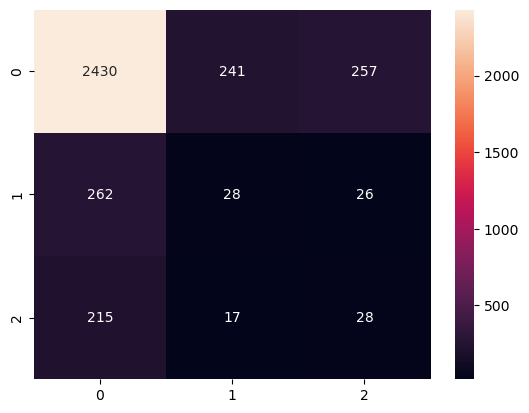

In [19]:
Y_train_pred = rf.predict(X_train)
Y_test_pred = rf.predict(X_test)

cm = confusion_matrix(Y_test, Y_test_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

### Scores de performance

Récapitulatif des métriques finales sur le jeu de test (accuracy, F1 macro, rapport de classification complet).

In [20]:
# Metriques finales
print("Accuracy (train) :", accuracy_score(Y_train, Y_train_pred))
print("Accuracy (test)  :", accuracy_score(Y_test, Y_test_pred))
print()
print("F1-Score macro (train) :", f1_score(Y_train, Y_train_pred, average="macro", zero_division=0))
print("F1-Score macro (test)  :", f1_score(Y_test,  Y_test_pred,  average="macro", zero_division=0))
print()
print("Rapport de classification complet :")
print(classification_report(
    Y_test, Y_test_pred,
    target_names=["Pas de maintenance", "Maintenance mineure", "Maintenance majeure"],
    zero_division=0
))


Accuracy (train) : 0.884845890410959
Accuracy (test)  : 0.7094748858447488

F1-Score macro (train) : 0.7752719175460053
F1-Score macro (test)  : 0.3413338984330314

Rapport de classification complet :
                     precision    recall  f1-score   support

 Pas de maintenance       0.84      0.83      0.83      2928
Maintenance mineure       0.10      0.09      0.09       316
Maintenance majeure       0.09      0.11      0.10       260

           accuracy                           0.71      3504
          macro avg       0.34      0.34      0.34      3504
       weighted avg       0.71      0.71      0.71      3504



---
## 6. Sauvegarde du meilleur modèle

On compare tous les runs et on sauvegarde le modèle avec le meilleur F1 macro test.

In [ ]:
print("\n" + "="*60)
print(f"Meilleur modele : {best_run['name']}")
print(f"F1 macro Test  : {best_run['f1_test']:.4f}")
print(f"Parametres     : {best_run['params']}")
print("=" * 60)

# --- Sauvegarde locale ---
model_path        = Path("../models/best_model.pkl")
preprocessor_path = Path("../models/preprocessor.pkl")
joblib.dump(best_run["model"], model_path)
joblib.dump(preprocessor, preprocessor_path)
print(f"\nModele sauvegarde        : {model_path}")
print(f"Preprocesseur sauvegarde : {preprocessor_path}")

# --- Upload S3 ---
S3_BUCKET    = "windscan"
S3_REGION    = "eu-north-1"
S3_MODEL_KEY = "models/"

s3 = boto3.client(
    "s3", region_name=S3_REGION,
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
)

for local, key in [
    (model_path,        S3_MODEL_KEY + "best_model.pkl"),
    (preprocessor_path, S3_MODEL_KEY + "preprocessor.pkl"),
]:
    s3.upload_file(str(local.resolve()), S3_BUCKET, key)
    print(f"Upload S3 OK : s3://{S3_BUCKET}/{key}")

---
## Conclusion

Ce notebook a couvert l'ensemble du pipeline de Machine Learning pour la maintenance prédictive des éoliennes :

- **EDA** : le dataset est globalement propre, avec quelques valeurs manquantes et un fort déséquilibre de classes (label 0 majoritaire).
- **Nettoyage** : suppression de 3 colonnes peu informatives (`Turbine_ID`, `Ambient_Temp_C`, `Humidity_pct`). Le dataset nettoyé est sauvegardé dans `data/processed/`.
- **Modèles testés** : Baseline naïve → Régression Logistique → Lasso → **Random Forest** (vainqueur).
- **Random Forest optimisé** : meilleur compromis biais/variance, F1-Score macro test autour de **0.58–0.62** selon les hyperparamètres.

**Points d'amélioration possibles :**
- Feature engineering temporel (lags, moyennes glissantes) pour exploiter la nature séquentielle des données
- Gestion du déséquilibre de classes via SMOTE ou oversampling
- Entraînement conjoint Turbine 1 + Turbine 2 avec validation croisée

Le modèle final est sauvegardé via `src/train_model.py` dans le dossier `models/`.